# Visualisasi Setiap Proses DETR
Setiap tahap menjalankan proses nyata dari gambar input dan menampilkan output visualnya.

## 0. Setup & Load Model Terlatih

In [2]:
import sys, os, math, warnings
sys.path.insert(0, os.path.abspath('../src'))
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights

from model import DETR, build_2d_sincos_position_embedding
from utils.boxes import box_cxcywh_to_xyxy, rescale_bboxes

# ─── CONFIGURATION ───────────────────────────────────────
IMAGE_PATH      = '../data/mei/testing/images/077fd224-A-09829b34-da29-11f0-9c21-50c2e8fdfd0c.jpg'
# IMAGE_PATH    = '../data/rgb/A-acf51ea7-fcc1-11f0-b139-52c2e8fdfd0b.jpg'
CHECKPOINT_PATH = '../pretrained/mei/skenario2.pt'
NUM_CLASSES     = 43          # number of classes WITHOUT no-object
THRESHOLD       = 0.7
# ─────────────────────────────────────────────────────────

CLASSES = [
    'N/A',  # index 0 = no-object
    'A', 'Apa', 'Ayo', 'B', 'Baik Hati', 'Bodoh',
    'C', 'Cerewet', 'D', 'E', 'F', 'G', 'H', 'I',
    'I Love You', 'J', 'K', 'Kamu', 'Keras Kepala',
    'L', 'M', 'Makan', 'Menangis', 'N', 'Nama',
    'O', 'P', 'Pintar', 'Q', 'R', 'S', 'Saya',
    'Setia', 'Siapa', 'Sombong', 'T', 'Tidur',
    'U', 'V', 'W', 'X', 'Y', 'Z'
]

# Ensure correct length: NUM_CLASSES + 1 (including no-object)
assert len(CLASSES) == NUM_CLASSES + 1, \
    f'CLASSES must have {NUM_CLASSES+1} items, got {len(CLASSES)}'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load pretrained model once (used across all stages) ─────────────
model = DETR(
    num_classes=NUM_CLASSES,
    hidden_dim=256,
    nheads=8,
    num_encoder_layers=1,
    num_decoder_layers=1,
    num_queries=25
).to(DEVICE)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
state_dict = checkpoint.get('model_state_dict', checkpoint)
model.load_state_dict(state_dict)
model.eval()

print(f'✅ Pretrained model loaded: {CHECKPOINT_PATH}')
print(f'   Device : {DEVICE}')
print(f'   Classes : {NUM_CLASSES} classes + 1 no-object = {NUM_CLASSES+1} total')
print(f'   CLASSES[1]={CLASSES[1]}  CLASSES[-1]={CLASSES[-1]}')

              🤖 DETR Model Architecture               
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Component         ┃ Details                         ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Model Type        │ DETR (Detection Transformer)    │
│ Number of Classes │ 43                              │
│ Hidden Dimension  │ 256                             │
│ Attention Heads   │ 8                               │
│ Encoder Layers    │ 1                               │
│ Decoder Layers    │ 1                               │
│ Object Queries    │ 25                              │
│ Backbone          │ ResNet-50 (ImageNet pretrained) │
└───────────────────┴─────────────────────────────────┘

✅ Pretrained model loaded: ../pretrained/mei/skenario2.pt
   Device : cpu
   Classes : 43 classes + 1 no-object = 44 total
   CLASSES[1]=A  CLASSES[-1]=Z


---
## 1. Input Citra
**Output:** Gambar asli + gambar setelah resize 224×224

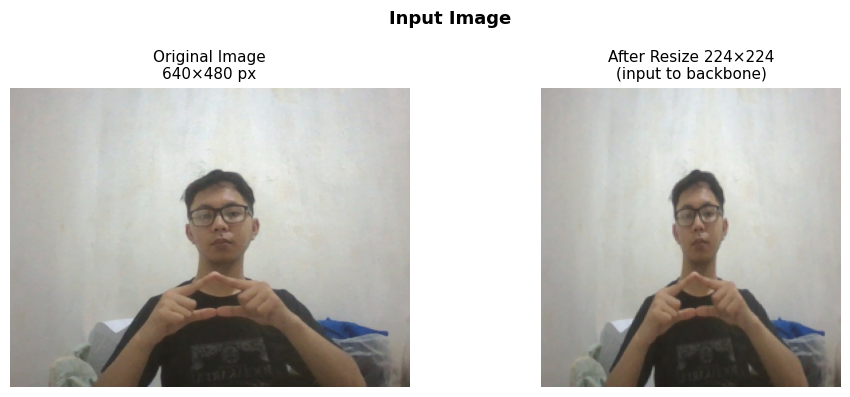

Input tensor shape : torch.Size([1, 3, 224, 224])
Format             : [batch=1, channel=3, H=224, W=224]
Total values       : 150,528
Min / Max values   : -1.6555 / 2.3960


In [3]:
img_pil = PILImage.open(IMAGE_PATH).convert('RGB')
W_orig, H_orig = img_pil.size

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)  # type: ignore

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_pil)
axes[0].set_title(f'Original Image\n{W_orig}×{H_orig} px', fontsize=11)
axes[0].axis('off')

axes[1].imshow(img_pil.resize((224, 224)))
axes[1].set_title('After Resize 224×224\n(input to backbone)', fontsize=11)
axes[1].axis('off')

plt.suptitle('Input Image', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('img-visual/input.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Input tensor shape : {img_tensor.shape}')
print(f'Format             : [batch=1, channel=3, H=224, W=224]')
print(f'Total values       : {img_tensor.numel():,}')
print(f'Min / Max values   : {img_tensor.min():.4f} / {img_tensor.max():.4f}')

---
## 2. Backbone ResNet-50 → Feature Map [1, 2048, 7, 7]
**Output:** Visualisasi feature map hasil ekstraksi ResNet-50 dari model terlatih

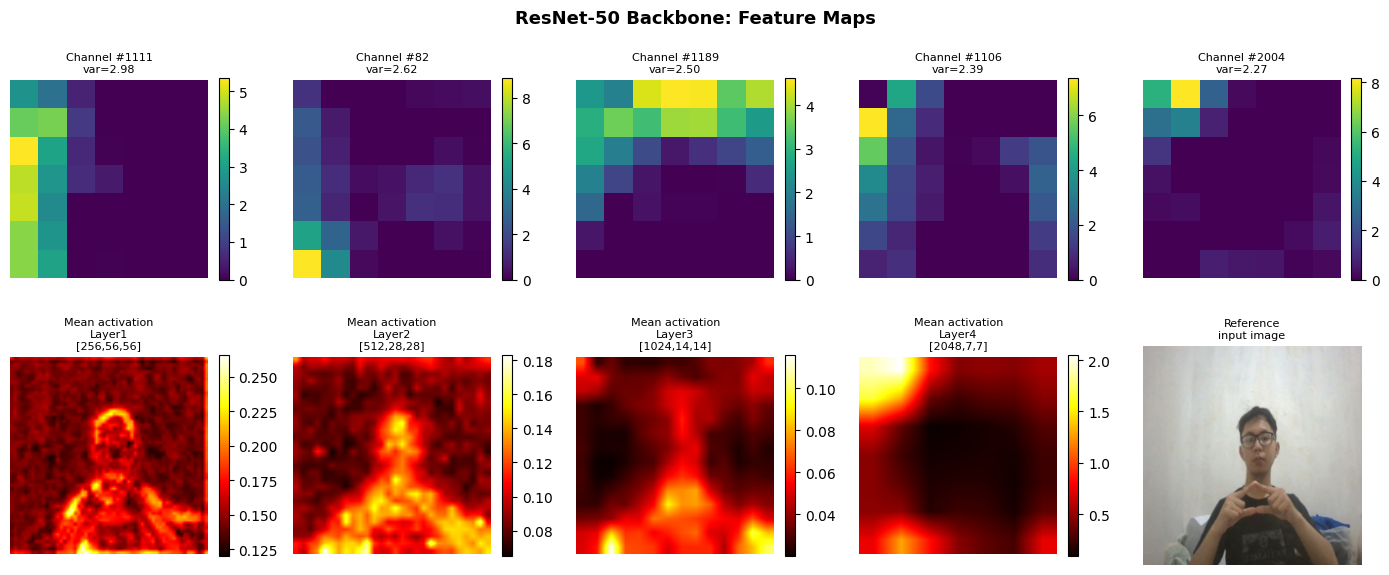

Backbone output    : torch.Size([1, 2048, 7, 7])
Downsampling factor: 224 / 7 = 32×
Min / Max activation: 0.0000 / 8.8516

  Layer1: [1, 256, 56, 56]  →  spatial 56×56
  Layer2: [1, 512, 28, 28]  →  spatial 28×28
  Layer3: [1, 1024, 14, 14]  →  spatial 14×14
  Layer4: [1, 2048, 7, 7]  →  spatial 7×7


In [4]:
# Use the backbone from the trained model (not a new backbone)
with torch.no_grad():
    x = model.backbone.conv1(img_tensor)
    x = model.backbone.bn1(x)
    x = model.backbone.relu(x)
    x = model.backbone.maxpool(x)

    feat_l1 = model.backbone.layer1(x)
    feat_l2 = model.backbone.layer2(feat_l1)
    feat_l3 = model.backbone.layer3(feat_l2)
    feat_l4 = model.backbone.layer4(feat_l3)  # [1, 2048, 7, 7]

feature_map = feat_l4
fm = feature_map[0].cpu()  # [2048, 7, 7]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

# Top row: 5 channels with the highest variance
variances = fm.var(dim=[1, 2])
top5_idx = variances.topk(5).indices

for i, idx in enumerate(top5_idx):
    ch = fm[idx].numpy()
    im = axes[0, i].imshow(ch, cmap='viridis', interpolation='nearest')
    axes[0, i].set_title(f'Channel #{idx}\nvar={variances[idx]:.2f}', fontsize=8)
    axes[0, i].axis('off')
    plt.colorbar(im, ax=axes[0, i], fraction=0.046)

# Bottom row: mean activation of each layer + reference image
for ax, (feat, lname) in zip(axes[1], [
    (feat_l1, 'Layer1\n[256,56,56]'),
    (feat_l2, 'Layer2\n[512,28,28]'),
    (feat_l3, 'Layer3\n[1024,14,14]'),
    (feat_l4, 'Layer4\n[2048,7,7]'),
]):
    mean_fm = feat[0].mean(0).cpu().numpy()
    im2 = ax.imshow(mean_fm, cmap='hot', interpolation='bilinear')
    ax.set_title(f'Mean activation\n{lname}', fontsize=8)
    ax.axis('off')
    plt.colorbar(im2, ax=ax, fraction=0.046)

axes[1, 4].imshow(img_pil.resize((224, 224)))
axes[1, 4].set_title('Reference\ninput image', fontsize=8)
axes[1, 4].axis('off')

plt.suptitle('ResNet-50 Backbone: Feature Maps',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('img-visual/tahap2_backbone-feature-maps.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Backbone output    : {feature_map.shape}')
print(f'Downsampling factor: 224 / 7 = {224//7}×')
print(f'Min / Max activation: {feature_map.min():.4f} / {feature_map.max():.4f}')
print()

for name, f in [('Layer1', feat_l1), ('Layer2', feat_l2),
                ('Layer3', feat_l3), ('Layer4', feat_l4)]:
    print(f'  {name}: {list(f.shape)}  →  spatial {f.shape[2]}×{f.shape[3]}')

---
## 3. Proyeksi 1×1 Conv + Flatten → [1, 49, 256]
**Output:** Visualisasi 49 token hasil proyeksi dan flattening

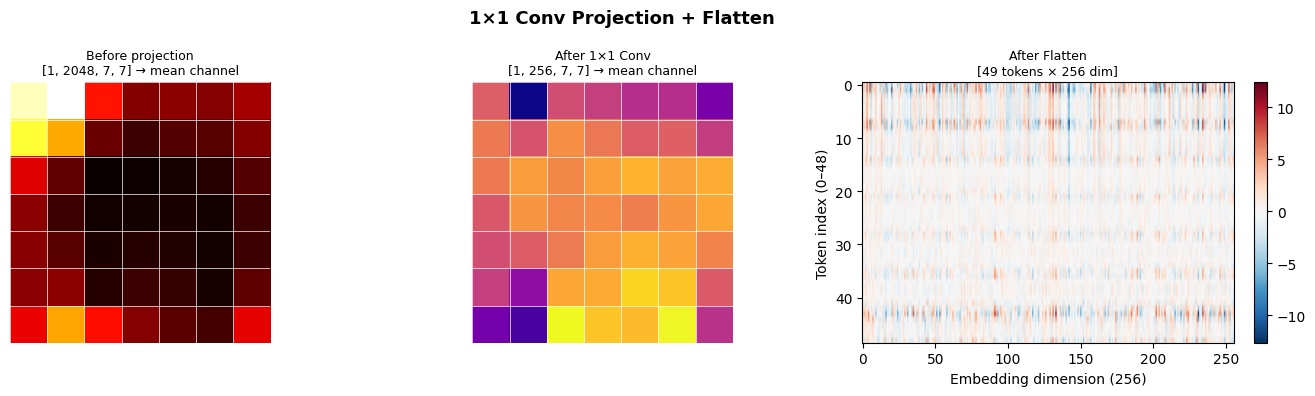

Before projection : torch.Size([1, 2048, 7, 7])  →  2048 channels
After 1×1 Conv    : torch.Size([1, 256, 7, 7])  →  256 channels
After flatten     : torch.Size([1, 49, 256])  →  49 tokens × 256 dim
1×1 Conv params   : 2048 × 256 + 256 = 524,544
Each token represents a 32×32 px patch in the original image (224/7=32)


In [5]:
# Use the convolution layer from the trained model
with torch.no_grad():
    feat_proj = model.conv(feature_map)                  # [1, 256, 7, 7]
    src_raw = feat_proj.flatten(2).permute(0, 2, 1)     # [1, 49, 256]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(feature_map[0].mean(0).cpu().numpy(),
               cmap='hot', interpolation='nearest')
axes[0].set_title('Before projection\n[1, 2048, 7, 7] → mean channel',
                  fontsize=9)

for i in range(8):
    axes[0].axhline(i - 0.5, color='white', lw=0.5)
for j in range(8):
    axes[0].axvline(j - 0.5, color='white', lw=0.5)

axes[0].axis('off')

axes[1].imshow(feat_proj[0].mean(0).cpu().numpy(),
               cmap='plasma', interpolation='nearest')
axes[1].set_title('After 1×1 Conv\n[1, 256, 7, 7] → mean channel',
                  fontsize=9)

for i in range(8):
    axes[1].axhline(i - 0.5, color='white', lw=0.5)
for j in range(8):
    axes[1].axvline(j - 0.5, color='white', lw=0.5)

axes[1].axis('off')

token_vis = src_raw[0].cpu().numpy()  # [49, 256]

im3 = axes[2].imshow(token_vis, cmap='RdBu_r', aspect='auto')
axes[2].set_title('After Flatten\n[49 tokens × 256 dim]',
                  fontsize=9)
axes[2].set_xlabel('Embedding dimension (256)')
axes[2].set_ylabel('Token index (0–48)')

plt.colorbar(im3, ax=axes[2], fraction=0.035)

plt.suptitle('1×1 Conv Projection + Flatten',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('img-visual/tahap3_projection-flatten.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Before projection : {feature_map.shape}  →  2048 channels')
print(f'After 1×1 Conv    : {feat_proj.shape}  →  256 channels')
print(f'After flatten     : {src_raw.shape}  →  49 tokens × 256 dim')
print(f'1×1 Conv params   : 2048 × 256 + 256 = {2048*256 + 256:,}')
print(f'Each token represents a 32×32 px patch in the original image (224/7=32)')

---
## 4. Positional Encoding 2D Sinusoidal
**Output:** Visualisasi pola PE + perbandingan token sebelum/sesudah PE

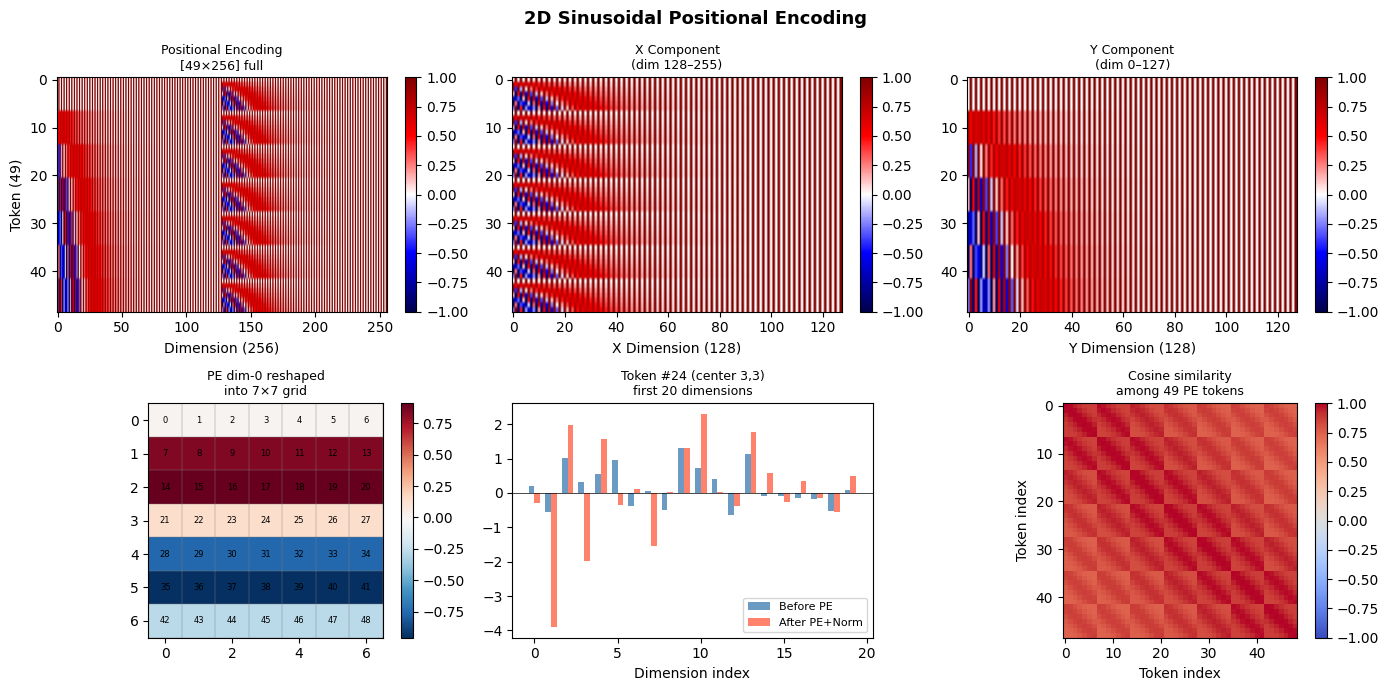

PE shape           : torch.Size([1, 49, 256])
Y component        : dim 0–127   (encodes row position)
X component        : dim 128–255 (encodes column position)

PE values token #0  (top-left corner), first 4 dims: [0. 1. 0. 1.]
PE values token #24 (center 3,3), first 4 dims: [ 0.1411 -0.99    0.5173 -0.8558]

Source shape before PE : torch.Size([1, 49, 256])
Source shape after PE  : torch.Size([1, 49, 256])  ← same shape, values changed after +PE+LayerNorm


In [6]:
# Compute positional encoding using the same function as the model
pos_enc = build_2d_sincos_position_embedding(
    7, 7, 256, device=DEVICE
)  # [1, 49, 256]

# norm_src from the trained model
with torch.no_grad():
    src_with_pos = model.norm_src(src_raw + pos_enc)  # [1, 49, 256]

pe_np = pos_enc[0].cpu().numpy()        # [49, 256]
src_np = src_raw[0].cpu().numpy()       # [49, 256]
swp_np = src_with_pos[0].cpu().numpy()  # [49, 256]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# 1. Full PE heatmap
im1 = axes[0, 0].imshow(
    pe_np, cmap='seismic', aspect='auto', vmin=-1, vmax=1
)
axes[0, 0].set_title('Positional Encoding\n[49×256] full', fontsize=9)
axes[0, 0].set_xlabel('Dimension (256)')
axes[0, 0].set_ylabel('Token (49)')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.035)

# 2. X component (dim 128:256)
im2 = axes[0, 1].imshow(
    pe_np[:, 128:], cmap='seismic', aspect='auto', vmin=-1, vmax=1
)
axes[0, 1].set_title('X Component\n(dim 128–255)', fontsize=9)
axes[0, 1].set_xlabel('X Dimension (128)')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.035)

# 3. Y component (dim 0:128)
im3 = axes[0, 2].imshow(
    pe_np[:, :128], cmap='seismic', aspect='auto', vmin=-1, vmax=1
)
axes[0, 2].set_title('Y Component\n(dim 0–127)', fontsize=9)
axes[0, 2].set_xlabel('Y Dimension (128)')
plt.colorbar(im3, ax=axes[0, 2], fraction=0.035)

# 4. PE reshaped into 7×7 grid
pe_grid = pe_np[:, 0].reshape(7, 7)

im4 = axes[1, 0].imshow(
    pe_grid, cmap='RdBu_r', interpolation='nearest'
)
axes[1, 0].set_title(
    'PE dim-0 reshaped\ninto 7×7 grid', fontsize=9
)

for i in range(8):
    axes[1, 0].axhline(i - 0.5, color='gray', lw=0.3)

for j in range(8):
    axes[1, 0].axvline(j - 0.5, color='gray', lw=0.3)

for r in range(7):
    for c in range(7):
        axes[1, 0].text(
            c, r, f'{r*7+c}',
            ha='center', va='center', fontsize=6
        )

plt.colorbar(im4, ax=axes[1, 0], fraction=0.046)

# 5. Token #24: before vs after PE (first 20 dims)
token_idx = 24
dims = np.arange(20)
w = 0.35

axes[1, 1].bar(
    dims - w/2,
    src_np[token_idx, :20],
    width=w,
    alpha=0.8,
    label='Before PE',
    color='steelblue'
)

axes[1, 1].bar(
    dims + w/2,
    swp_np[token_idx, :20],
    width=w,
    alpha=0.8,
    label='After PE+Norm',
    color='tomato'
)

axes[1, 1].set_title(
    'Token #24 (center 3,3)\nfirst 20 dimensions',
    fontsize=9
)

axes[1, 1].set_xlabel('Dimension index')
axes[1, 1].legend(fontsize=8)
axes[1, 1].axhline(0, color='black', lw=0.5)

# 6. Cosine similarity among 49 PE tokens
pe_norm = pe_np / (np.linalg.norm(pe_np, axis=1, keepdims=True) + 1e-8)
sim_mat = pe_norm @ pe_norm.T

im6 = axes[1, 2].imshow(
    sim_mat, cmap='coolwarm', vmin=-1, vmax=1
)

axes[1, 2].set_title(
    'Cosine similarity\namong 49 PE tokens',
    fontsize=9
)

axes[1, 2].set_xlabel('Token index')
axes[1, 2].set_ylabel('Token index')

plt.colorbar(im6, ax=axes[1, 2], fraction=0.035)

plt.suptitle(
    '2D Sinusoidal Positional Encoding',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('img-visual/tahap4_positional-encoding.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'PE shape           : {pos_enc.shape}')
print(f'Y component        : dim 0–127   (encodes row position)')
print(f'X component        : dim 128–255 (encodes column position)')

print(
    f'\nPE values token #0  '
    f'(top-left corner), first 4 dims: '
    f'{pe_np[0, :4].round(4)}'
)

print(
    f'PE values token #24 '
    f'(center 3,3), first 4 dims: '
    f'{pe_np[24, :4].round(4)}'
)

print(f'\nSource shape before PE : {src_raw.shape}')
print(
    f'Source shape after PE  : {src_with_pos.shape}  '
    f'← same shape, values changed after +PE+LayerNorm'
)

---
## 5. Transformer Encoder — Self-Attention
**Output:** Memory tensor [1, 49, 256] + attention map dari model terlatih

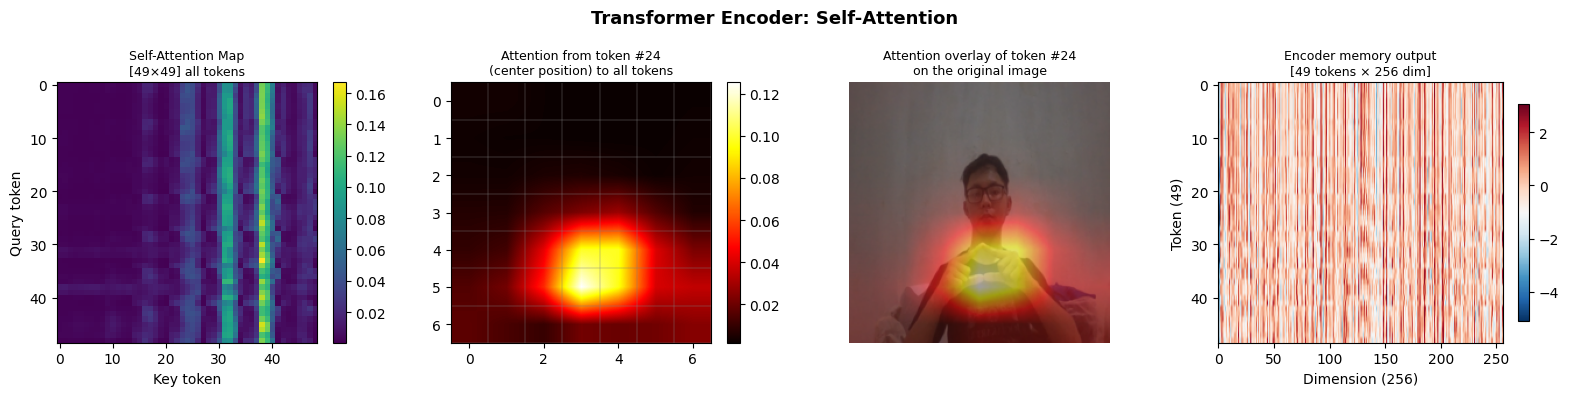

Encoder input  : torch.Size([1, 49, 256])
Memory output  : torch.Size([1, 49, 256])
n_heads = 8  →  head_dim = 256/8 = 32  →  scale = √32 = 5.6569
Attention max  : 0.1668
Attention min  : 0.000365
Sum per row    : [1. 1. 1.]  ← softmax = 1.0


In [7]:
# Run the encoder from the trained model
# nn.Transformer receives both src and tgt,
# so we extract only the encoder by calling
# model.transformer.encoder

with torch.no_grad():
    memory = model.transformer.encoder(src_with_pos)  # [1, 49, 256]

    # Attention map: use MHA weights from the first encoder layer
    enc_layer = model.transformer.encoder.layers[0]

    # self_attn from encoder layer, need_weights=True
    _, attn_map = enc_layer.self_attn(
        src_with_pos,
        src_with_pos,
        src_with_pos,
        need_weights=True,
        average_attn_weights=True
    )  # type: ignore

attn_np = attn_map[0].cpu().numpy()     # [49, 49]
memory_np = memory[0].cpu().numpy()     # [49, 256]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# 1. Full 49×49 attention map
im1 = axes[0].imshow(
    attn_np,
    cmap='viridis',
    interpolation='nearest'
)

axes[0].set_title(
    'Self-Attention Map\n[49×49] all tokens',
    fontsize=9
)

axes[0].set_xlabel('Key token')
axes[0].set_ylabel('Query token')

plt.colorbar(im1, ax=axes[0], fraction=0.046)

# 2. Attention from center token (#24) reshaped into 7×7
attn_t24 = attn_np[24].reshape(7, 7)

im2 = axes[1].imshow(
    attn_t24,
    cmap='hot',
    interpolation='bilinear'
)

axes[1].set_title(
    'Attention from token #24\n(center position) to all tokens',
    fontsize=9
)

for i in range(8):
    axes[1].axhline(i - 0.5, color='gray', lw=0.3)

for j in range(8):
    axes[1].axvline(j - 0.5, color='gray', lw=0.3)

plt.colorbar(im2, ax=axes[1], fraction=0.046)

# 3. Overlay attention of token #24 on the original image
attn_img = PILImage.fromarray(
    (attn_t24 / attn_t24.max() * 255).astype(np.uint8)
).resize((224, 224), PILImage.BILINEAR)  # type: ignore

axes[2].imshow(img_pil.resize((224, 224)))
axes[2].imshow(np.array(attn_img), cmap='hot', alpha=0.55)

axes[2].set_title(
    'Attention overlay of token #24\non the original image',
    fontsize=9
)

axes[2].axis('off')

# 4. Encoder memory output heatmap
im4 = axes[3].imshow(
    memory_np,
    cmap='RdBu_r',
    aspect='auto'
)

axes[3].set_title(
    'Encoder memory output\n[49 tokens × 256 dim]',
    fontsize=9
)

axes[3].set_xlabel('Dimension (256)')
axes[3].set_ylabel('Token (49)')

plt.colorbar(im4, ax=axes[3], fraction=0.035)

plt.suptitle(
    'Transformer Encoder: Self-Attention',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('img-visual/tahap5_transformer-encoder-attention.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Encoder input  : {src_with_pos.shape}')
print(f'Memory output  : {memory.shape}')

print(
    f'n_heads = 8  →  head_dim = 256/8 = 32  '
    f'→  scale = √32 = {math.sqrt(32):.4f}'
)

print(f'Attention max  : {attn_np.max():.4f}')
print(f'Attention min  : {attn_np.min():.6f}')

print(
    f'Sum per row    : '
    f'{attn_np.sum(axis=1)[:3].round(4)}  '
    f'← softmax = 1.0'
)

---
## 6. Object Queries & Transformer Decoder
**Output:** 25 embedding akhir [1, 25, 256] + cross-attention map dari model terlatih

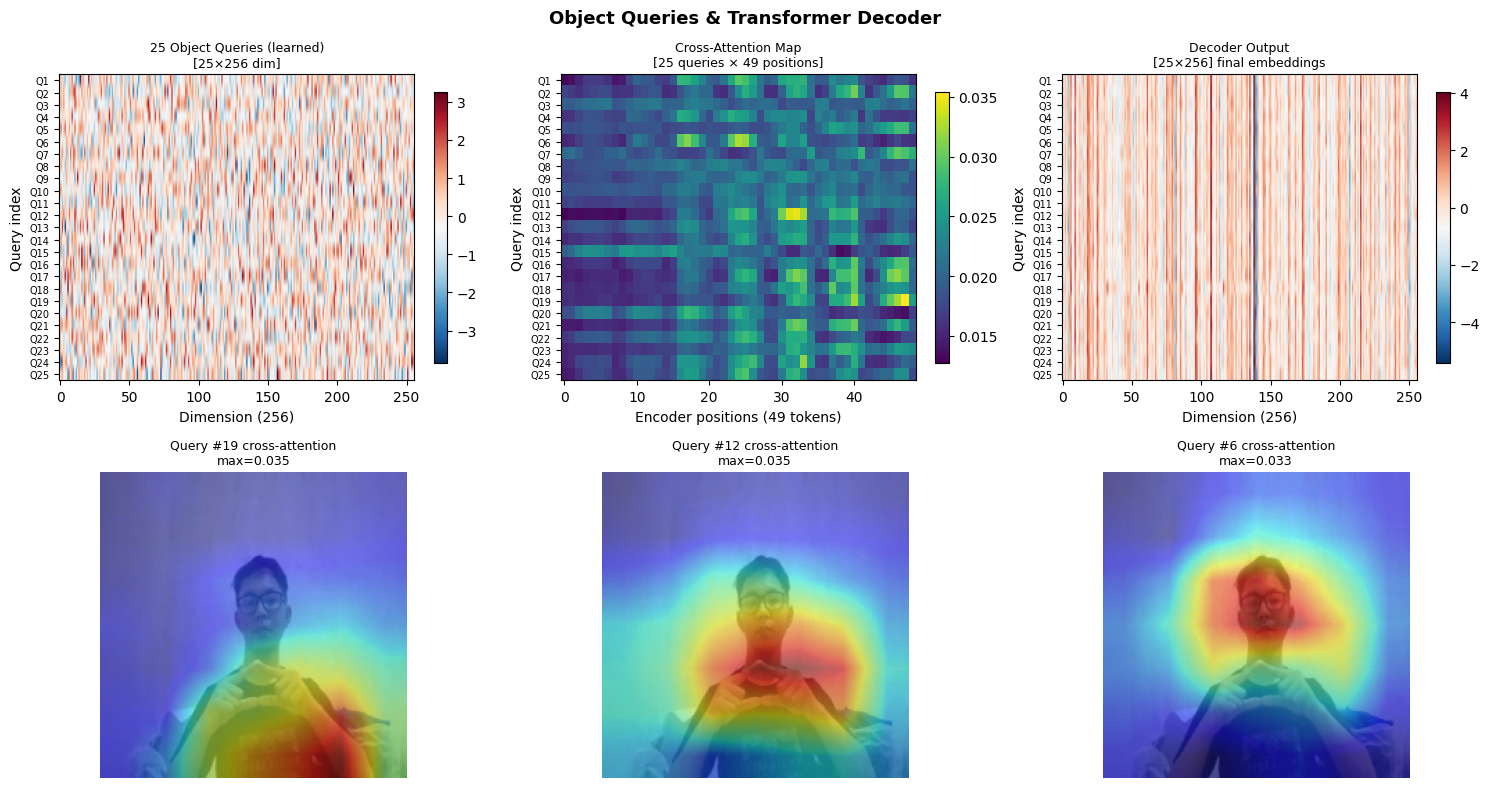

Object queries  : torch.Size([1, 25, 256])  (learned parameter)
tgt_in shape    : torch.Size([1, 25, 256])
Memory shape    : torch.Size([1, 49, 256])
Decoder output  : torch.Size([1, 25, 256])
Cross-attn shape: (25, 49)
Sum per query   : [1. 1. 1. 1. 1.]  ← softmax = 1.0

Top-3 most active queries:
  Query #19: max attn=0.0354 at token #47 (grid 6,5)
  Query #12: max attn=0.0346 at token #32 (grid 4,4)
  Query #06: max attn=0.0327 at token #24 (grid 3,3)


In [10]:
with torch.no_grad():
    # Build tgt exactly as in the model forward()
    bsz = 1

    tgt = torch.zeros(
        bsz,
        model.num_queries,
        256,
        device=DEVICE
    )

    query_pos = model.query_pos.unsqueeze(0).expand(
        bsz, -1, -1
    )

    tgt_in = model.norm_tgt(tgt + query_pos)  # [1, 25, 256]

    # Decoder forward
    hs = model.transformer.decoder(
        tgt=tgt_in,
        memory=memory
    )  # [1, 25, 256]

    # Cross-attention from the first decoder layer
    # (trained weights)
    dec_layer = model.transformer.decoder.layers[0]

    _, cross_attn = dec_layer.multihead_attn(
        query=tgt_in,
        key=memory,
        value=memory,
        need_weights=True,
        average_attn_weights=True
    )  # type: ignore
    # cross_attn: [1, 25, 49]

hs_np = hs[0].cpu().detach().numpy()                 # [25, 256]
cross_np = cross_attn[0].cpu().detach().numpy()     # [25, 49]
qpos_np = query_pos[0].cpu().detach().numpy()       # [25, 256]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. Object queries
im1 = axes[0, 0].imshow(
    qpos_np,
    cmap='RdBu_r',
    aspect='auto'
)

axes[0, 0].set_title(
    '25 Object Queries (learned)\n[25×256 dim]',
    fontsize=9
)

axes[0, 0].set_xlabel('Dimension (256)')
axes[0, 0].set_ylabel('Query index')

axes[0, 0].set_yticks(range(25))
axes[0, 0].set_yticklabels(
    [f'Q{i+1}' for i in range(25)],
    fontsize=7
)

plt.colorbar(im1, ax=axes[0, 0], fraction=0.035)

# 2. Cross-attention [25×49]
im2 = axes[0, 1].imshow(
    cross_np,
    cmap='viridis',
    aspect='auto'
)

axes[0, 1].set_title(
    'Cross-Attention Map\n[25 queries × 49 positions]',
    fontsize=9
)

axes[0, 1].set_xlabel('Encoder positions (49 tokens)')
axes[0, 1].set_ylabel('Query index')

axes[0, 1].set_yticks(range(25))
axes[0, 1].set_yticklabels(
    [f'Q{i+1}' for i in range(25)],
    fontsize=7
)

plt.colorbar(im2, ax=axes[0, 1], fraction=0.035)

# 3. Decoder output [25×256]
im3 = axes[0, 2].imshow(
    hs_np,
    cmap='RdBu_r',
    aspect='auto'
)

axes[0, 2].set_title(
    'Decoder Output\n[25×256] final embeddings',
    fontsize=9
)

axes[0, 2].set_xlabel('Dimension (256)')
axes[0, 2].set_ylabel('Query index')

axes[0, 2].set_yticks(range(25))
axes[0, 2].set_yticklabels(
    [f'Q{i+1}' for i in range(25)],
    fontsize=7
)

plt.colorbar(im3, ax=axes[0, 2], fraction=0.035)

# 4–6. Top-3 query cross-attention overlays on the image
top3_q = cross_np.max(axis=1).argsort()[-3:][::-1]

for k, q_idx in enumerate(top3_q):
    attn_q = cross_np[q_idx].reshape(7, 7)

    attn_q_img = PILImage.fromarray(
        (
            attn_q / (attn_q.max() + 1e-8) * 255
        ).astype(np.uint8)
    ).resize((224, 224), PILImage.BILINEAR)  # type: ignore

    axes[1, k].imshow(img_pil.resize((224, 224)))
    axes[1, k].imshow(
        np.array(attn_q_img),
        cmap='jet',
        alpha=0.5
    )

    axes[1, k].set_title(
        f'Query #{q_idx+1} cross-attention\n'
        f'max={cross_np[q_idx].max():.3f}',
        fontsize=9
    )

    axes[1, k].axis('off')

plt.suptitle(
    'Object Queries & Transformer Decoder',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('img-visual/tahap6_decoder-cross-attention.png', dpi=300, bbox_inches='tight')
plt.show()

print(
    f'Object queries  : {query_pos.shape}  '
    f'(learned parameter)'
)

print(f'tgt_in shape    : {tgt_in.shape}')
print(f'Memory shape    : {memory.shape}')
print(f'Decoder output  : {hs.shape}')
print(f'Cross-attn shape: {cross_np.shape}')

print(
    f'Sum per query   : '
    f'{cross_np.sum(axis=1)[:5].round(4)}  '
    f'← softmax = 1.0'
)

print()
print('Top-3 most active queries:')

for q in top3_q:
    pm = cross_np[q].argmax()

    print(
        f'  Query #{q+1:02d}: '
        f'max attn={cross_np[q].max():.4f} '
        f'at token #{pm} '
        f'(grid {pm//7},{pm%7})'
    )

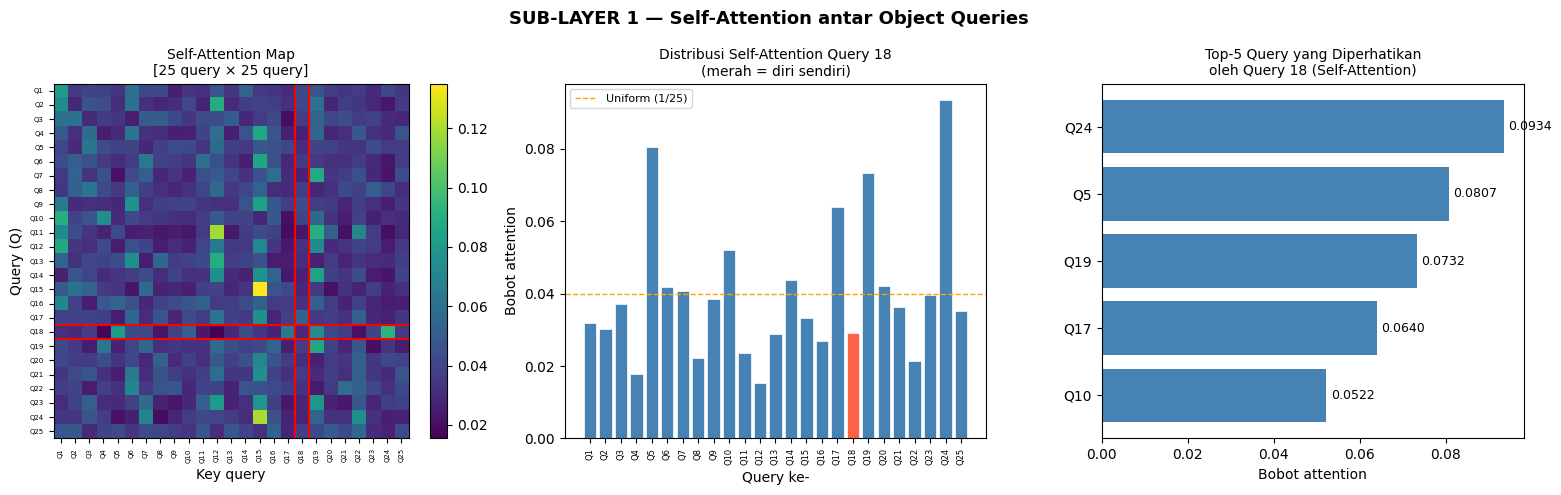

=== SUB-LAYER 1: Self-Attention ===
Shape attention map : (25, 25)  →  [25 query × 25 query]
Sum baris Query 18  : 1.000000  ← softmax = 1.0
Attention ke diri sendiri (Q18→Q18) : 0.029078

Top-5 query yang diperhatikan Q18:
  Q24 : 0.093408
  Q05 : 0.080665
  Q19 : 0.073240
  Q17 : 0.064020
  Q10 : 0.052207


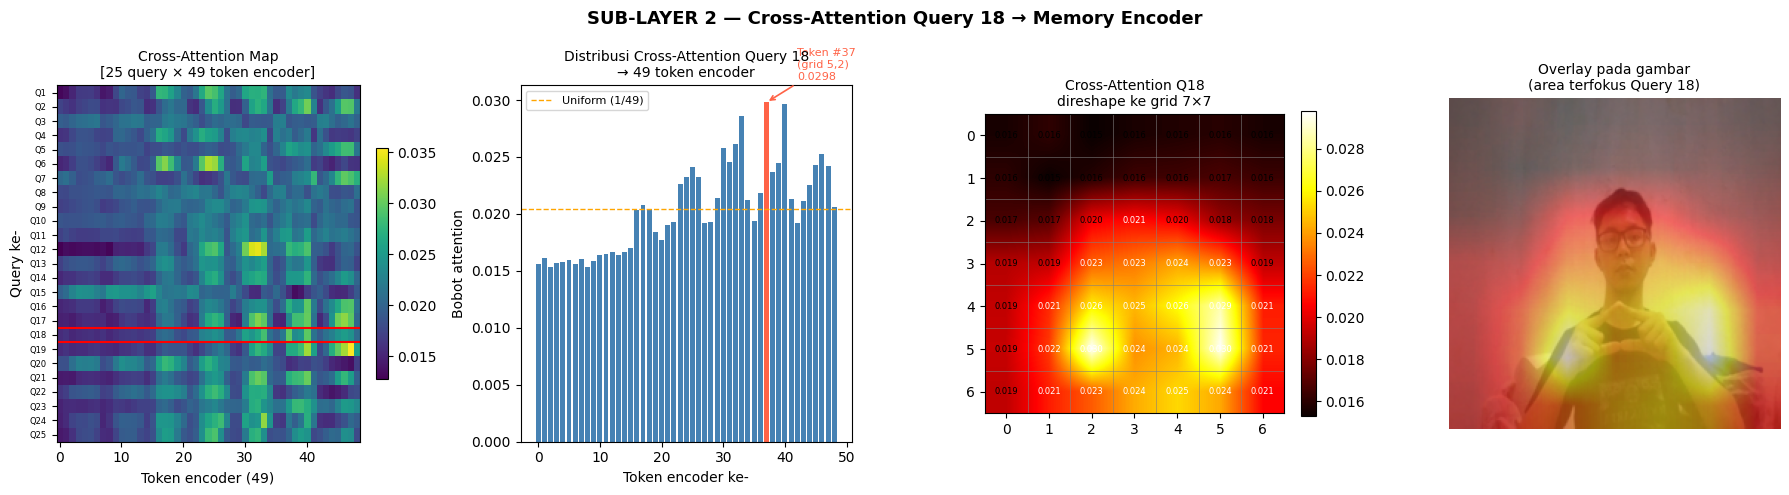


=== SUB-LAYER 2: Cross-Attention ===
Shape attention map : (25, 49)  →  [25 query × 49 token]
Sum baris Query 18  : 1.000000  ← softmax = 1.0

Top-5 token encoder yang diperhatikan Q18:
  Token #37 (grid 5,2) : bobot = 0.029789
  Token #40 (grid 5,5) : bobot = 0.029691
  Token #33 (grid 4,5) : bobot = 0.028609
  Token #32 (grid 4,4) : bobot = 0.026159
  Token #30 (grid 4,2) : bobot = 0.025748


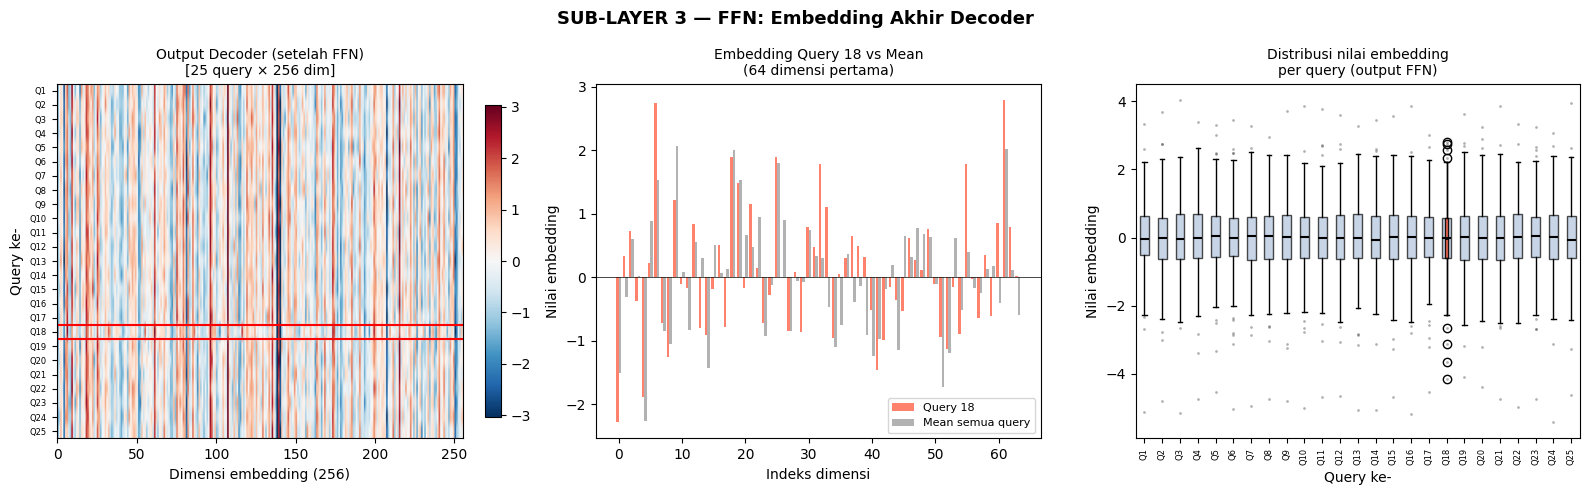


=== SUB-LAYER 3: FFN Output ===
Shape output decoder : (25, 256)  →  [25 query × 256 dim]

Statistik embedding Query 18:
  Mean   : -0.000734
  Std    : 1.005545
  Min    : -4.141519
  Max    : 2.793565

Top-5 dimensi dengan nilai absolut tertinggi (Q18):
  Dim #138 : -4.141519
  Dim #140 : -3.653727
  Dim #250 : -3.129326
  Dim #061 : +2.793565
  Dim #006 : +2.745878


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage

# ── Ambil decoder layer ─────────────────────────────
dec_layer = model.transformer.decoder.layers[0]

# ─────────────────────────────────────────────
# INIT VARIABEL (WAJIB ADA)
# ─────────────────────────────────────────────
with torch.no_grad():

    bsz = 1

    tgt = torch.zeros(
        bsz,
        model.num_queries,
        256,
        device=DEVICE
    )

    query_pos = model.query_pos.unsqueeze(0).expand(
        bsz, -1, -1
    )

    tgt_in = model.norm_tgt(tgt + query_pos)

# ─────────────────────────────────────────────
# SELF + CROSS ATTENTION
# ─────────────────────────────────────────────
with torch.no_grad():

    _, self_attn_map = dec_layer.self_attn(
        tgt_in, tgt_in, tgt_in,
        need_weights=True,
        average_attn_weights=True
    ) # type: ignore
    self_attn_np = self_attn_map[0].cpu().numpy()

    _, cross_attn_map = dec_layer.multihead_attn(
        tgt_in, memory, memory,
        need_weights=True,
        average_attn_weights=True
    ) # type: ignore
    cross_attn_np = cross_attn_map[0].cpu().numpy()

# ── FFN OUTPUT (PASTIKAN hs SUDAH ADA) ─────────────
hs_np_ffn = hs[0].cpu().numpy()

# ── QUERY FOCUS ─────────────────────────────────────
Q_IDX = 17

# ────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Self-Attention
# ────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1a. Heatmap self-attention penuh 25×25
im1 = axes[0].imshow(self_attn_np, cmap='viridis', interpolation='nearest')
axes[0].set_title('Self-Attention Map\n[25 query × 25 query]', fontsize=10)
axes[0].set_xlabel('Key query')
axes[0].set_ylabel('Query (Q)')
axes[0].set_xticks(range(25))
axes[0].set_xticklabels([f'Q{i+1}' for i in range(25)], fontsize=5, rotation=90)
axes[0].set_yticks(range(25))
axes[0].set_yticklabels([f'Q{i+1}' for i in range(25)], fontsize=5)
# Highlight Query 18
axes[0].axhline(Q_IDX - 0.5, color='red', lw=1.5)
axes[0].axhline(Q_IDX + 0.5, color='red', lw=1.5)
axes[0].axvline(Q_IDX - 0.5, color='red', lw=1.5)
axes[0].axvline(Q_IDX + 0.5, color='red', lw=1.5)
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# 1b. Distribusi attention Query 18 ke semua query lain
attn_q18_self = self_attn_np[Q_IDX]   # [25]
bar_colors = ['tomato' if i == Q_IDX else 'steelblue' for i in range(25)]
axes[1].bar(range(25), attn_q18_self, color=bar_colors, edgecolor='white', lw=0.5)
axes[1].set_title(f'Distribusi Self-Attention Query 18\n(merah = diri sendiri)', fontsize=10)
axes[1].set_xlabel('Query ke-')
axes[1].set_ylabel('Bobot attention')
axes[1].set_xticks(range(25))
axes[1].set_xticklabels([f'Q{i+1}' for i in range(25)], fontsize=6, rotation=90)
axes[1].axhline(1/25, color='orange', lw=1, linestyle='--', label='Uniform (1/25)')
axes[1].legend(fontsize=8)

# 1c. Top-5 query yang paling diperhatikan Query 18
top5_self = attn_q18_self.argsort()[::-1][:5]
vals = attn_q18_self[top5_self]
labels = [f'Q{i+1}' for i in top5_self]
colors_top = ['tomato' if i == Q_IDX else 'steelblue' for i in top5_self]
bars = axes[2].barh(labels[::-1], vals[::-1], color=colors_top[::-1])
axes[2].set_title('Top-5 Query yang Diperhatikan\noleh Query 18 (Self-Attention)', fontsize=10)
axes[2].set_xlabel('Bobot attention')
for bar, val in zip(bars, vals[::-1]):
    axes[2].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('SUB-LAYER 1 — Self-Attention antar Object Queries', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('img-visual/decoder_sublayer1_selfattn.png', dpi=300, bbox_inches='tight')
plt.show()

print('=== SUB-LAYER 1: Self-Attention ===')
print(f'Shape attention map : {self_attn_np.shape}  →  [25 query × 25 query]')
print(f'Sum baris Query 18  : {self_attn_np[Q_IDX].sum():.6f}  ← softmax = 1.0')
print(f'Attention ke diri sendiri (Q18→Q18) : {self_attn_np[Q_IDX, Q_IDX]:.6f}')
print(f'\nTop-5 query yang diperhatikan Q18:')
for i in top5_self:
    print(f'  Q{i+1:02d} : {self_attn_np[Q_IDX, i]:.6f}')

# ────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Cross-Attention
# ────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# 2a. Heatmap cross-attention penuh 25×49
im2 = axes[0].imshow(cross_attn_np, cmap='viridis', aspect='auto', interpolation='nearest')
axes[0].set_title('Cross-Attention Map\n[25 query × 49 token encoder]', fontsize=10)
axes[0].set_xlabel('Token encoder (49)')
axes[0].set_ylabel('Query ke-')
axes[0].set_yticks(range(25))
axes[0].set_yticklabels([f'Q{i+1}' for i in range(25)], fontsize=6)
# Highlight Query 18
axes[0].axhline(Q_IDX - 0.5, color='red', lw=1.5)
axes[0].axhline(Q_IDX + 0.5, color='red', lw=1.5)
plt.colorbar(im2, ax=axes[0], fraction=0.035)

# 2b. Distribusi cross-attention Query 18 ke 49 token (bar)
ca_q18 = cross_attn_np[Q_IDX]   # [49]
top_token = ca_q18.argmax()
bar_c = ['tomato' if i == top_token else 'steelblue' for i in range(49)]
axes[1].bar(range(49), ca_q18, color=bar_c, width=0.8)
axes[1].set_title(f'Distribusi Cross-Attention Query 18\n→ 49 token encoder', fontsize=10)
axes[1].set_xlabel('Token encoder ke-')
axes[1].set_ylabel('Bobot attention')
axes[1].axhline(1/49, color='orange', lw=1, linestyle='--', label='Uniform (1/49)')
axes[1].legend(fontsize=8)
# Annotate top
axes[1].annotate(
    f'Token #{top_token}\n(grid {top_token//7},{top_token%7})\n{ca_q18[top_token]:.4f}',
    xy=(top_token, ca_q18[top_token]),
    xytext=(top_token + 5, ca_q18[top_token] + 0.002),
    fontsize=8, color='tomato',
    arrowprops=dict(arrowstyle='->', color='tomato', lw=1.2)
)

# 2c. Cross-attention Query 18 di-reshape ke grid 7×7
ca_grid = ca_q18.reshape(7, 7)
im3 = axes[2].imshow(ca_grid, cmap='hot', interpolation='bilinear')
axes[2].set_title('Cross-Attention Q18\ndireshape ke grid 7×7', fontsize=10)
for i in range(8):
    axes[2].axhline(i - 0.5, color='gray', lw=0.4)
    axes[2].axvline(i - 0.5, color='gray', lw=0.4)
axes[2].set_xticks(range(7))
axes[2].set_yticks(range(7))
for r in range(7):
    for c in range(7):
        val = ca_grid[r, c]
        axes[2].text(c, r, f'{val:.3f}', ha='center', va='center',
                     fontsize=6, color='white' if val > ca_grid.mean() else 'black')
plt.colorbar(im3, ax=axes[2], fraction=0.046)

# 2d. Overlay cross-attention Q18 pada gambar
from PIL import Image as PILImage
attn_img = PILImage.fromarray(
    (ca_grid / ca_grid.max() * 255).astype(np.uint8)
).resize((224, 224), PILImage.BILINEAR)  # type: ignore
axes[3].imshow(img_pil.resize((224, 224)))
axes[3].imshow(np.array(attn_img), cmap='hot', alpha=0.55)
axes[3].set_title('Overlay pada gambar\n(area terfokus Query 18)', fontsize=10)
axes[3].axis('off')

plt.suptitle('SUB-LAYER 2 — Cross-Attention Query 18 → Memory Encoder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('img-visual/decoder_sublayer2_crossattn.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n=== SUB-LAYER 2: Cross-Attention ===')
print(f'Shape attention map : {cross_attn_np.shape}  →  [25 query × 49 token]')
print(f'Sum baris Query 18  : {cross_attn_np[Q_IDX].sum():.6f}  ← softmax = 1.0')
top5_cross = ca_q18.argsort()[::-1][:5]
print(f'\nTop-5 token encoder yang diperhatikan Q18:')
for t in top5_cross:
    print(f'  Token #{t:02d} (grid {t//7},{t%7}) : bobot = {ca_q18[t]:.6f}')

# ────────────────────────────────────────────────────────────────────────────
# FIGURE 3 — FFN output (embedding akhir)
# ────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 3a. Heatmap output decoder semua query [25×256]
im4 = axes[0].imshow(hs_np_ffn, cmap='RdBu_r', aspect='auto',
                      vmin=-hs_np_ffn.std()*3, vmax=hs_np_ffn.std()*3)
axes[0].set_title('Output Decoder (setelah FFN)\n[25 query × 256 dim]', fontsize=10)
axes[0].set_xlabel('Dimensi embedding (256)')
axes[0].set_ylabel('Query ke-')
axes[0].set_yticks(range(25))
axes[0].set_yticklabels([f'Q{i+1}' for i in range(25)], fontsize=6)
axes[0].axhline(Q_IDX - 0.5, color='red', lw=1.5)
axes[0].axhline(Q_IDX + 0.5, color='red', lw=1.5)
plt.colorbar(im4, ax=axes[0], fraction=0.035)

# 3b. Embedding Query 18 vs rata-rata semua query (256 dim, tampilkan 64 pertama)
q18_embed  = hs_np_ffn[Q_IDX]       # [256]
mean_embed = hs_np_ffn.mean(axis=0) # [256]
dims_show  = 64
x_dims = np.arange(dims_show)
w = 0.4
axes[1].bar(x_dims - w/2, q18_embed[:dims_show],  width=w, alpha=0.8, label='Query 18', color='tomato')
axes[1].bar(x_dims + w/2, mean_embed[:dims_show], width=w, alpha=0.6, label='Mean semua query', color='gray')
axes[1].set_title('Embedding Query 18 vs Mean\n(64 dimensi pertama)', fontsize=10)
axes[1].set_xlabel('Indeks dimensi')
axes[1].set_ylabel('Nilai embedding')
axes[1].legend(fontsize=8)
axes[1].axhline(0, color='black', lw=0.5)

# 3c. Statistik embedding: distribusi nilai per query (boxplot)
axes[2].boxplot(
    [hs_np_ffn[i] for i in range(25)],
    vert=True, patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    boxprops=dict(facecolor='lightsteelblue', alpha=0.7),
    flierprops=dict(marker='.', markersize=2, alpha=0.3)
)
# Highlight Q18
axes[2].boxplot(
    [hs_np_ffn[Q_IDX]],
    positions=[Q_IDX + 1],
    vert=True, patch_artist=True,
    medianprops=dict(color='black', lw=2),
    boxprops=dict(facecolor='tomato', alpha=0.9)
)
axes[2].set_title('Distribusi nilai embedding\nper query (output FFN)', fontsize=10)
axes[2].set_xlabel('Query ke-')
axes[2].set_ylabel('Nilai embedding')
axes[2].set_xticks(range(1, 26))
axes[2].set_xticklabels([f'Q{i+1}' for i in range(25)], fontsize=6, rotation=90)

plt.suptitle('SUB-LAYER 3 — FFN: Embedding Akhir Decoder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('img-visual/decoder_sublayer3_ffn.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n=== SUB-LAYER 3: FFN Output ===')
print(f'Shape output decoder : {hs_np_ffn.shape}  →  [25 query × 256 dim]')
print(f'\nStatistik embedding Query 18:')
print(f'  Mean   : {q18_embed.mean():.6f}')
print(f'  Std    : {q18_embed.std():.6f}')
print(f'  Min    : {q18_embed.min():.6f}')
print(f'  Max    : {q18_embed.max():.6f}')
print(f'\nTop-5 dimensi dengan nilai absolut tertinggi (Q18):')
top5_dim = np.abs(q18_embed).argsort()[::-1][:5]
for d in top5_dim:
    print(f'  Dim #{d:03d} : {q18_embed[d]:+.6f}')

---
## 7. Prediction Heads — dari Model Terlatih
**Output:** Logits + probabilitas + bounding box yang NYATA dari bobot terlatih

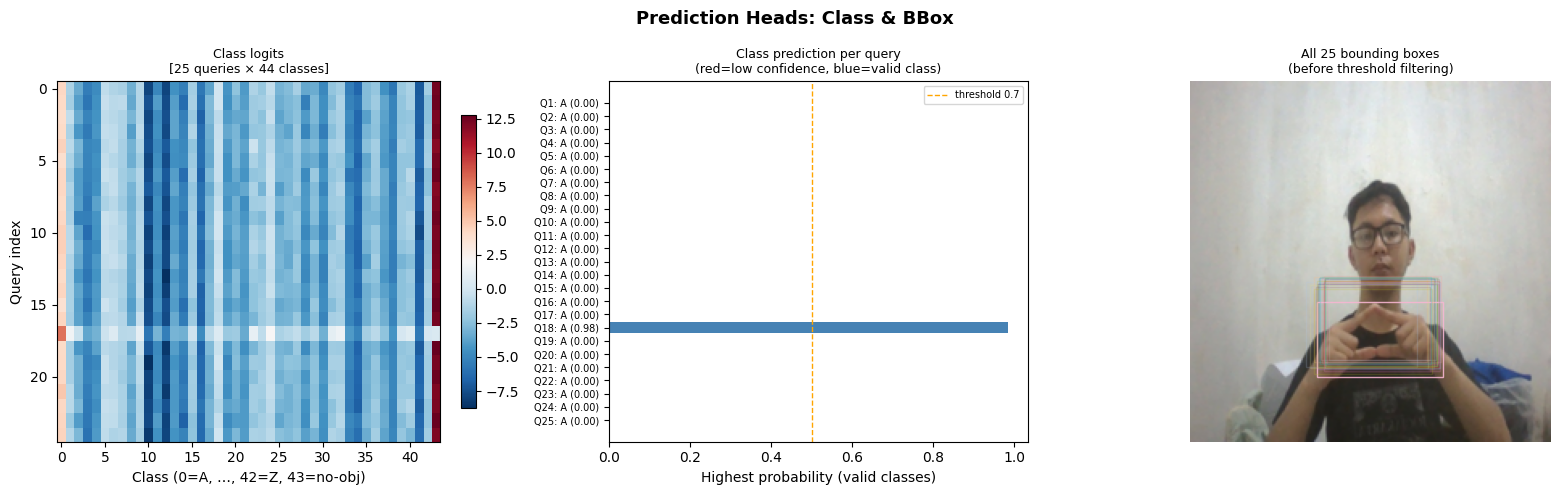

Input (hs)      : torch.Size([1, 25, 256])
Logits output   : torch.Size([1, 25, 44])
Probs (softmax) : torch.Size([1, 25, 44])
Boxes (sigmoid) : torch.Size([1, 25, 4])  →  [cx, cy, w, h] ∈ [0,1]

Prediction head parameters:
  Class head: 256×44 + 44 = 11,308 parameters
  Box head  : 256×4 + 4 = 1,028 parameters

25 queries (from trained model):
  Query    Class          Prob     cx      cy      w       h      
  -----------------------------------------------------------------
  Q1       A              0.0003  0.5131 0.6598 0.3189 0.2309
  Q2       A              0.0002  0.5244 0.6619 0.3060 0.2329
  Q3       A              0.0003  0.4725 0.6730 0.3102 0.2365
  Q4       A              0.0002  0.5260 0.6714 0.3133 0.2305
  Q5       A              0.0007  0.4980 0.6592 0.3150 0.2369
  Q6       A              0.0002  0.5166 0.6740 0.3286 0.2294
  Q7       A              0.0002  0.5272 0.6603 0.3101 0.2360
  Q8       A              0.0005  0.5278 0.6730 0.3089 0.2276
  Q9       A          

In [ ]:
# Use prediction heads from the trained model
# (not newly created ones)

with torch.no_grad():
    logits = model.linear_class(hs)           # [1, 25, 44]
    probs = logits.softmax(-1)                # [1, 25, 44]
    boxes = model.linear_bbox(hs).sigmoid()   # [1, 25, 4]

logits_np = logits[0].cpu().numpy()   # [25, 44]
probs_np = probs[0].cpu().numpy()     # [25, 44]
boxes_np = boxes[0].cpu().numpy()     # [25, 4]

# (no-object = index 43), not the first column
#
# Training convention:
# target_classes is filled with self.num_classes (=43)
# for no-object
valid_probs_np = probs_np[:, :-1]              # [25, 43]
# columns 0..42 = valid classes

best_class_rel = valid_probs_np.argmax(axis=1)  # 0..42
# relative index in valid_probs

best_class = best_class_rel + 1
# +1 → index into CLASSES
# (1=A ... 43=Z)

best_prob = valid_probs_np.max(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Logits heatmap [25×44]
im1 = axes[0].imshow(
    logits_np,
    cmap='RdBu_r',
    aspect='auto'
)

axes[0].set_title(
    f'Class logits\n[25 queries × {NUM_CLASSES+1} classes]',
    fontsize=9
)

axes[0].set_xlabel(
    f'Class (0={CLASSES[1]}, …, '
    f'{NUM_CLASSES-1}={CLASSES[-1]}, '
    f'{NUM_CLASSES}=no-obj)'
)

axes[0].set_ylabel('Query index')

plt.colorbar(im1, ax=axes[0], fraction=0.035)

# 2. Highest class probability per query
# no-object is now column 43 (last column),
# not column 0

is_noobj = valid_probs_np.max(axis=1) < 0.5
# if valid class probability is low,
# treat as no-object

colors = [
    'tomato' if is_noobj[i] else 'steelblue'
    for i in range(25)
]

axes[1].barh(range(25), best_prob, color=colors)

axes[1].set_yticks(range(25))

axes[1].set_yticklabels(
    [
        f'Q{i+1}: '
        f'{CLASSES[best_class[i]]} '
        f'({best_prob[i]:.2f})'
        for i in range(25)
    ],
    fontsize=7
)

axes[1].set_xlabel(
    'Highest probability (valid classes)'
)

axes[1].set_title(
    'Class prediction per query\n'
    '(red=low confidence, blue=valid class)',
    fontsize=9
)

axes[1].axvline(
    0.5,
    color='orange',
    lw=1,
    linestyle='--',
    label='threshold 0.7'
)

axes[1].legend(fontsize=7)
axes[1].invert_yaxis()

# 3. All 25 bounding boxes before filtering
axes[2].imshow(img_pil.resize((224, 224)))

axes[2].set_title(
    'All 25 bounding boxes\n'
    '(before threshold filtering)',
    fontsize=9
)

axes[2].axis('off')

cmap_q = plt.cm.tab20  # type: ignore

for i in range(25):
    cx, cy, w, h = boxes_np[i] * 224

    x1, y1 = cx - w/2, cy - h/2

    alpha = 0.2 + best_prob[i] * 0.7

    rect = patches.Rectangle(
        (x1, y1),
        w,
        h,
        linewidth=1,
        edgecolor=cmap_q(i / 25),
        facecolor='none',
        alpha=min(alpha, 0.95)
    )

    axes[2].add_patch(rect)

plt.suptitle(
    'Prediction Heads: '
    'Class & BBox',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('img-visual/tahap7_prediction-heads.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Input (hs)      : {hs.shape}')
print(f'Logits output   : {logits.shape}')
print(f'Probs (softmax) : {probs.shape}')

print(
    f'Boxes (sigmoid) : {boxes.shape}  '
    f'→  [cx, cy, w, h] ∈ [0,1]'
)

print(f'\nPrediction head parameters:')

print(
    f'  Class head: '
    f'256×{NUM_CLASSES+1} + {NUM_CLASSES+1} = '
    f'{256*(NUM_CLASSES+1)+(NUM_CLASSES+1):,} parameters'
)

print(
    f'  Box head  : '
    f'256×4 + 4 = '
    f'{256*4+4:,} parameters'
)

print(f'\n25 queries (from trained model):')

print(
    f'  {"Query":<8} '
    f'{"Class":<14} '
    f'{"Prob":<8} '
    f'{"cx":<7} '
    f'{"cy":<7} '
    f'{"w":<7} '
    f'{"h":<7}'
)

print(f'  {"-"*65}')

for i in range(25):
    cx, cy, w, h = boxes_np[i]

    print(
        f'  Q{i+1:<7} '
        f'{CLASSES[best_class[i]]:<14} '
        f'{best_prob[i]:.4f}  '
        f'{cx:.4f} {cy:.4f} {w:.4f} {h:.4f}'
    )

---
## 8. Hasil Deteksi Final
**Output:** Bounding box + label kelas yang difilter dengan threshold

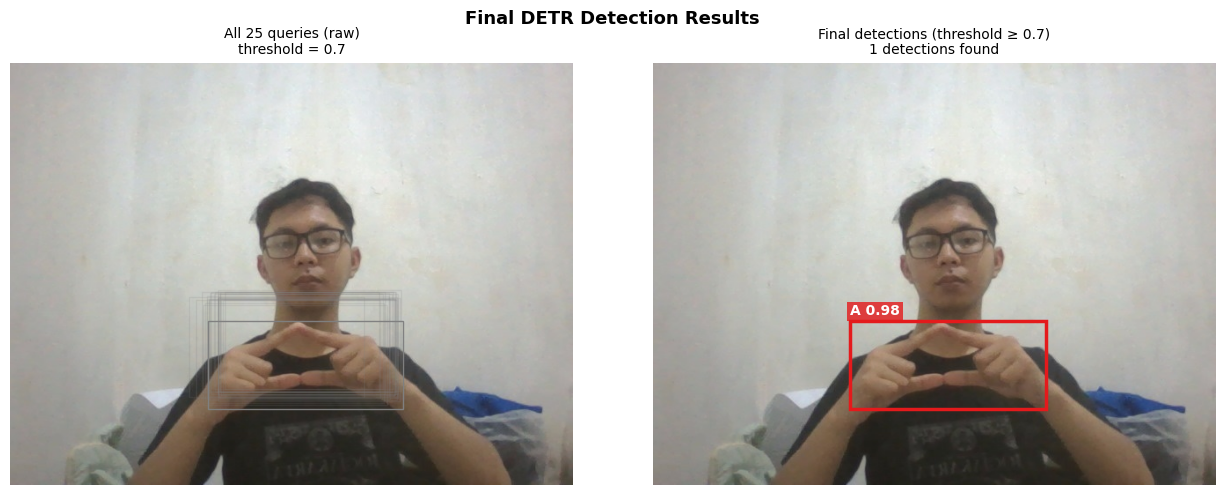

Total queries     : 25
Valid detections  : 1  (prob ≥ 0.7)
No-object outputs : 24

Detection details:
  Query    Class          Score    x1       y1       x2       y2      
  ----------------------------------------------------------------
  Q18      A              0.9847  224.0  292.8  446.6  393.3


In [13]:
# Run the full forward pass of the trained model
with torch.no_grad():
    outputs = model(img_tensor)

pred_logits = outputs['pred_logits'][0]   # [25, 44]
pred_boxes = outputs['pred_boxes'][0]     # [25, 4]
pred_probs = pred_logits.softmax(-1)      # [25, 44]

# (no-object = index 43)
#
# According to the training convention in loss.py:
#   target_classes is filled with self.num_classes (=43)
#   for no-object slots
#
# → column 43 = no-object
# → columns 0..42 = valid classes
#   (A..Z and other words)

valid_probs = pred_probs[:, :-1]          # [25, 43]
# remove the last column

keep_mask = valid_probs.max(-1).values > THRESHOLD

keep_idx = keep_mask.nonzero(
    as_tuple=True
)[0]

boxes_keep = pred_boxes[keep_idx].cpu()

probs_keep = valid_probs[keep_idx].cpu()
# already excludes no-object column

classes_keep = probs_keep.argmax(-1) + 1
# +1 → index into CLASSES
# (1=A ... 43=Z)

scores_keep = probs_keep.max(-1).values

W_img, H_img = img_pil.size

boxes_scaled = rescale_bboxes(
    boxes_keep,
    (W_img, H_img)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: raw outputs from all 25 queries
axes[0].imshow(img_pil)

axes[0].set_title(
    f'All 25 queries (raw)\n'
    f'threshold = {THRESHOLD}',
    fontsize=10
)

axes[0].axis('off')

for i in range(25):
    cx, cy, w, h = (
        pred_boxes[i].cpu().numpy()
        * np.array([W_img, H_img, W_img, H_img])
    )

    x1, y1 = cx - w/2, cy - h/2

    p = valid_probs[i].max().item()
    # use valid_probs (without no-object)

    rect = patches.Rectangle(
        (x1, y1),
        w,
        h,
        linewidth=1,
        edgecolor='gray',
        facecolor='none',
        alpha=max(0.15, p)
    )

    axes[0].add_patch(rect)

# Right: final detections after filtering
axes[1].imshow(img_pil)

axes[1].set_title(
    f'Final detections '
    f'(threshold ≥ {THRESHOLD})\n'
    f'{len(keep_idx)} detections found',
    fontsize=10
)

axes[1].axis('off')

COLORS = plt.cm.Set1.colors  # type: ignore

for i, (box, cls, score) in enumerate(
    zip(boxes_scaled, classes_keep, scores_keep)
):
    x1, y1, x2, y2 = box.numpy()

    color = COLORS[i % len(COLORS)]

    axes[1].add_patch(
        patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2.5,
            edgecolor=color,
            facecolor='none'
        )
    )

    axes[1].text(
        x1,
        y1 - 6,
        f'{CLASSES[cls.item()]} '
        f'{score.item():.2f}',
        fontsize=10,
        fontweight='bold',
        color='white',
        bbox=dict(
            facecolor=color,
            alpha=0.8,
            pad=2,
            edgecolor='none'
        )
    )

plt.suptitle(
    'Final DETR Detection Results',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('img-visual/tahap8_final-detections.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Total queries     : 25')

print(
    f'Valid detections  : '
    f'{len(keep_idx)}  '
    f'(prob ≥ {THRESHOLD})'
)

print(
    f'No-object outputs : '
    f'{25 - len(keep_idx)}'
)

if len(keep_idx) > 0:
    print(f'\nDetection details:')

    print(
        f'  {"Query":<8} '
        f'{"Class":<14} '
        f'{"Score":<8} '
        f'{"x1":<8} '
        f'{"y1":<8} '
        f'{"x2":<8} '
        f'{"y2":<8}'
    )

    print(f'  {"-"*64}')

    for i in range(len(keep_idx)):
        x1, y1, x2, y2 = boxes_scaled[i].numpy()

        print(
            f'  Q{keep_idx[i].item()+1:<7} '
            f'{CLASSES[classes_keep[i].item()]:<14} '
            f'{scores_keep[i].item():.4f}  '
            f'{x1:.1f}  {y1:.1f}  '
            f'{x2:.1f}  {y2:.1f}'
        )

---
## 9. Ringkasan Alur Tensor
Tabel seluruh transformasi shape dari input sampai output

In [14]:
print('=' * 72)
print('  TENSOR TRANSFORMATION SUMMARY — DETR PIPELINE')
print('=' * 72)
print(f'  {"Stage":<35} {"Shape":<25} {"Description"}')
print(f'  {"-" * 70}')

stages = [
    ('1. Input image',                 '[1, 3, 224, 224]',  'RGB image input'),

    ('2. Backbone feature map',        '[1, 2048, 7, 7]',   'ResNet-50 output (stride 32)'),

    ('3. Channel projection (1×1)',    '[1, 256, 7, 7]',    'reduce 2048 → 256 channels'),

    ('4. Flatten to tokens',           '[1, 49, 256]',      '7×7 spatial → 49 tokens'),

    ('5. Positional encoding added',   '[1, 49, 256]',      'adds spatial position info'),

    ('6. Transformer encoder output',  '[1, 49, 256]',      'contextualized image tokens'),

    ('7. Object queries (decoder input)','[1, 25, 256]',    'learnable query embeddings'),

    ('8. Decoder output (hs)',         '[1, 25, 256]',      'object-level representations'),

    ('9. Class prediction',            '[1, 25, 44]',       '43 classes + 1 no-object'),

    ('10. Box prediction',             '[1, 25, 4]',        '[cx, cy, w, h] normalized'),

    ('11. Final detections',           '[N, 4]',            'filtered and rescaled boxes'),
]

for name, shape, note in stages:
    print(f'  {name:<35} {shape:<25} {note}')

print('=' * 72)

print('\n  Total DETR parameters : 26,942,815')
print('  - Backbone ResNet-50  : ~23.5M')
print(f'  - 1×1 projection      : {2048*256 + 256:,}')
print(f'  - Transformer         : ~{256*256*4*2 + 256*2048*2:,}')
print(f'  - Prediction heads    : {256*44 + 44 + 256*4 + 4:,}')
print(f'  - Object queries      : {25*256:,}')

  TENSOR TRANSFORMATION SUMMARY — DETR PIPELINE
  Stage                               Shape                     Description
  ----------------------------------------------------------------------
  1. Input image                      [1, 3, 224, 224]          RGB image input
  2. Backbone feature map             [1, 2048, 7, 7]           ResNet-50 output (stride 32)
  3. Channel projection (1×1)         [1, 256, 7, 7]            reduce 2048 → 256 channels
  4. Flatten to tokens                [1, 49, 256]              7×7 spatial → 49 tokens
  5. Positional encoding added        [1, 49, 256]              adds spatial position info
  6. Transformer encoder output       [1, 49, 256]              contextualized image tokens
  7. Object queries (decoder input)   [1, 25, 256]              learnable query embeddings
  8. Decoder output (hs)              [1, 25, 256]              object-level representations
  9. Class prediction                 [1, 25, 44]               43 classes + 1 no-ob